# Week 2 — State & Memory

**도메인**: 마인크래프트 지식 에이전트  
**추가 기능**: InMemorySaver로 thread_id 기반 short-term memory 적용

## 변경 사항
- `MemorySaver` checkpointer 추가
- `thread_id` 로 대화 상태 분리
- 같은 thread → 이전 대화 기억 / 다른 thread → 새 대화 시작

## 그래프 구조


In [1]:
import sys
import os


sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
os.environ['LANGSMITH_TRACING'] = 'false'
os.environ['LANGSMITH_TRACING_V2'] = 'false'

## 1. 그래프 로드 및 시각화

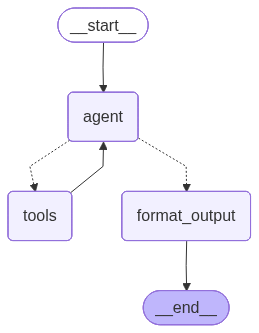

In [3]:
from graph import graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 2. 헬퍼 함수 정의

In [ ]:
from langchain_core.messages import HumanMessage
from schema import MinecraftAgentResponse


def run_agent(question: str, thread_id: str = "default") -> None:
    result = graph.invoke(
        {"messages": [HumanMessage(content=question)], "structured_output": None},
        config={"configurable": {"thread_id": thread_id}, "recursion_limit": 15},
    )
    resp = result.get("structured_output")
    if resp:
        print(f"[{thread_id}] Q: {question}")
        print(f"[{thread_id}] A: {resp.answer}")
        print()


print("헬퍼 함수 정의 완료")

헬퍼 함수 정의 완료


## 3. 테스트

### 같은 thread_id — 이전 대화를 기억하는지 확인

In [ ]:
# 첫 번째 질문
run_agent("다이아몬드 검 만드는 법 알려줘", thread_id="user_1")

In [ ]:
# 이전 대화를 기억하고 답해야 함
run_agent("방금 말한 재료 중 다이아몬드는 어디서 구해?", thread_id="user_1")

In [ ]:
# 대화가 더 이어짐
run_agent("그럼 나무 막대기는?", thread_id="user_1")

### 다른 thread_id — 이전 대화를 모르는지 확인

In [ ]:
# user_2는 위 대화를 전혀 모름
run_agent("방금 말한 재료 중 다이아몬드는 어디서 구해?", thread_id="user_2")

## 4. 그래프 노드/엣지 구조 확인

In [9]:
g = graph.get_graph()

print('노드 목록:')
for node in g.nodes:
    print(f'  - {node}')

print('\n엣지 목록:')
for edge in g.edges:
    cond = f' (조건: {edge.data})' if edge.data else ''
    print(f'  {edge.source} → {edge.target}{cond}')

노드 목록:
  - __start__
  - agent
  - tools
  - format_output
  - __end__

엣지 목록:
  __start__ → agent
  agent → format_output
  agent → tools
  tools → agent
  format_output → __end__
